In [39]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution
from scipy.stats import wasserstein_distance  
from scipy.stats import norm

T = 10
time_steps = np.arange(T)
n_normals = 100
n_radicals = 1
bins = 100
opinion_bins = np.arange(1, bins+1)
bin_edges = np.linspace(0, 1, bins+1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
beta = 10
alpha = 0.05
epsilon = 0.1
radical_weight= 10
initial_opinions = np.clip(np.random.normal(loc=0.4, scale=0.2, size=n_normals), 0, 1)

def phi(diff, beta):
    return 1 / (1 + np.exp(beta * (abs(diff)-epsilon)))

def simulate_continuous_model(opinions, radicals, n_normals, n_radicals, T):
    radicals = np.array(radicals).reshape((T, n_radicals))
    historique = [opinions.copy()]
    for t in range(T):
        rads = radicals[t]
        total_opinions = np.concatenate([opinions, rads])
        updated_opinions = np.copy(opinions)
        for i in range(n_normals):
            xi = opinions[i]
            xj = total_opinions
            influence_weights = phi(xi - xj, beta)
            influence_weights[i] = 0 
            influence_weights[-n_radicals:] *= radical_weight
            sum_weights = np.sum(influence_weights)
            if sum_weights > 0:
                influence = np.sum(influence_weights * (xj - xi)) / sum_weights
                updated_opinions[i] = xi + alpha * influence
        opinions = np.clip(updated_opinions, 0, 1)
        historique.append(opinions.copy())
    return opinions, np.array(historique)


#def wasserstein(n_normals, n_radicals, T, target_dist):
    def cost(u):
        final_opinions = simulate_continuous_model(u, n_normals, n_radicals, T)
        return wasserstein_distance(
            final_opinions,
            np.random.choice(bin_centers, size=len(final_opinions), p=target_dist)
        )
    return cost

def cost1(radicals ,n_normals, n_radicals, T):
    final_opinions = simulate_continuous_model(initial_opinions, radicals, n_normals, n_radicals, T)[0]
    cost = -np.sum(final_opinions)
    return cost

bounds = [(0, 1)] * (T * n_radicals)
result1 = differential_evolution(cost1, bounds, maxiter=40, args=(n_normals, n_radicals, T))
radicals1 = result1.x.reshape((T, n_radicals))
intermediate_opinions, historique1 = simulate_continuous_model(initial_opinions, result1.x, n_normals, n_radicals, T)

def cost2(radicals ,n_normals, n_radicals, T):
    final_opinions = simulate_continuous_model(initial_opinions, radicals, n_normals, n_radicals, T)[0]
    cost = np.sum(final_opinions)
    return cost

result2 = differential_evolution(cost2, bounds, maxiter=40, args=(n_normals, n_radicals, T))
radicals2 = result2.x.reshape((T, n_radicals))
final_opinions, historique2 = simulate_continuous_model(initial_opinions, result2.x, n_normals, n_radicals, T)


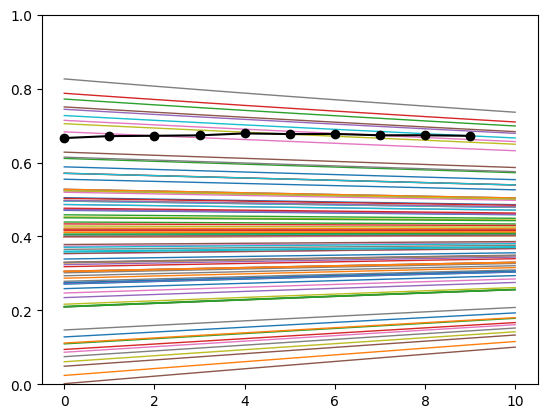

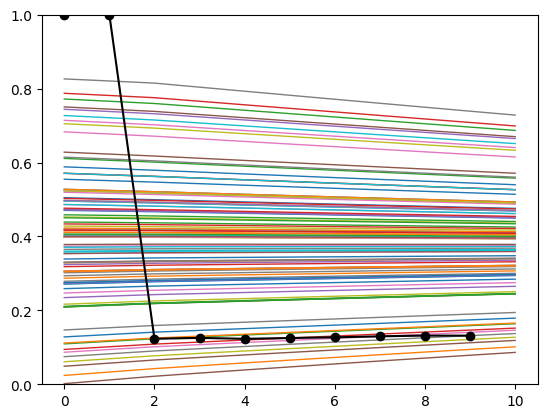

In [40]:
def historique_inter():
    for agent in range(n_normals):
        plt.plot(historique1[:, agent],alpha=1, linewidth=1)
    radicals_optimal = np.sort(radicals1)
    for i in range(n_radicals):
        radical_opinions_over_time = radicals_optimal[:, i]
        plt.plot(time_steps, radical_opinions_over_time, marker='o', linestyle='-', color = 'black')
    plt.ylim(0, 1)
    plt.show()

historique_inter()

def historique_fin():
    for agent in range(n_normals):
        plt.plot(historique2[:, agent],alpha=1, linewidth=1)
    radicals_optimal = np.sort(radicals2)
    for i in range(n_radicals):
        radical_opinions_over_time = radicals_optimal[:, i]
        plt.plot(time_steps, radical_opinions_over_time, marker='o', linestyle='-', color = 'black')
    plt.ylim(0, 1)
    plt.show()

historique_fin()


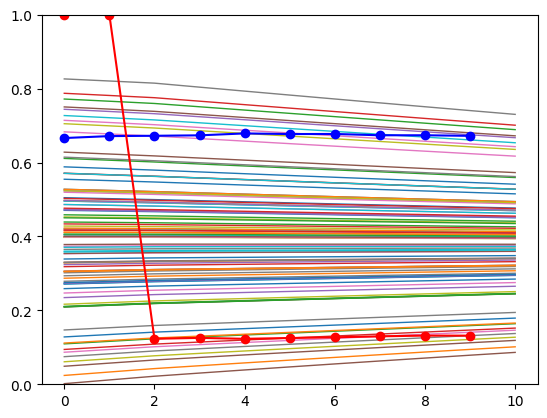

In [41]:
radicals = np.concatenate((radicals1, radicals2), axis = 1)

def simulate_both_continuous_model(opinions, radicals, n_normals, n_radicals, T):
    radicals = np.array(radicals).reshape((T, 2*n_radicals))
    historique = [opinions.copy()]
    for t in range(T):
        rads = radicals[t]
        total_opinions = np.concatenate([opinions, rads])
        updated_opinions = np.copy(opinions)
        for i in range(n_normals):
            xi = opinions[i]
            xj = total_opinions
            influence_weights = phi(xi - xj, beta)
            influence_weights[i] = 0 
            influence_weights[-n_radicals :] *= radical_weight
            sum_weights = np.sum(influence_weights)
            if sum_weights > 0:
                influence = np.sum(influence_weights * (xj - xi)) / sum_weights
                updated_opinions[i] = xi + alpha * influence
        opinions = np.clip(updated_opinions, 0, 1)
        historique.append(opinions.copy())
    return opinions, np.array(historique)

historique = simulate_both_continuous_model(initial_opinions, radicals, n_normals, n_radicals, T)[1]

def historique0():
    for agent in range(n_normals):
        plt.plot(historique[:, agent],alpha=1, linewidth=1)
    for i in range(n_radicals):
        radical_opinions_over_time = radicals1[:, i]
        plt.plot(time_steps, radical_opinions_over_time, marker='o', linestyle='-', color = 'blue')
    for i in range(n_radicals):
        radical_opinions_over_time = radicals2[:, i]
        plt.plot(time_steps, radical_opinions_over_time, marker='o', linestyle='-', color = 'red')
    plt.ylim(0, 1)
    plt.show()

historique0()